In [1]:
from pathlib import Path
import json
import shutil
import random

import numpy as np
import pandas as pd
import yaml

from PIL import Image

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "datasets" / "processed"

DATASETS = [
    "bottle",
    "pcb",
    "road",
    "steel",
    "textile",
    "welding",
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

PROCESSED_DATA.mkdir(
    parents=True,
    exist_ok=True
)

print("Inspectra — Data Preparation")
print("=" * 60)
print(f"Raw       : {RAW_DATA}")
print(f"Processed : {PROCESSED_DATA}")

Inspectra — Data Preparation
Raw       : d:\Inspectra\datasets\raw
Processed : d:\Inspectra\datasets\processed


In [2]:
def find_images(root):
    return [
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]


def copy_file(source, destination):
    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        source,
        destination
    )


def reset_directory(path):
    if path.exists():
        shutil.rmtree(path)

    path.mkdir(
        parents=True,
        exist_ok=True
    )

In [3]:
PREPARED_DATA = {
    "bottle": PROCESSED_DATA / "bottle",
    "pcb": PROCESSED_DATA / "pcb",
    "road": PROCESSED_DATA / "road",
    "steel": PROCESSED_DATA / "steel",
    "textile": PROCESSED_DATA / "textile",
    "welding": PROCESSED_DATA / "welding",
}

for path in PREPARED_DATA.values():
    path.mkdir(
        parents=True,
        exist_ok=True
    )

for name, path in PREPARED_DATA.items():
    print(
        f"{name:10} -> {path}"
    )

bottle     -> d:\Inspectra\datasets\processed\bottle
pcb        -> d:\Inspectra\datasets\processed\pcb
road       -> d:\Inspectra\datasets\processed\road
steel      -> d:\Inspectra\datasets\processed\steel
textile    -> d:\Inspectra\datasets\processed\textile
welding    -> d:\Inspectra\datasets\processed\welding


In [4]:
YOLO_DATASETS = [
    "bottle",
    "pcb",
    "textile",
    "welding",
]


def create_yolo_structure(dataset_name):

    root = PREPARED_DATA[
        dataset_name
    ]

    for split in [
        "train",
        "val",
        "test",
    ]:

        (root / split / "images").mkdir(
            parents=True,
            exist_ok=True
        )

        (root / split / "labels").mkdir(
            parents=True,
            exist_ok=True
        )


for dataset in YOLO_DATASETS:

    create_yolo_structure(
        dataset
    )

    print(
        f"Created YOLO structure: {dataset}"
    )

Created YOLO structure: bottle
Created YOLO structure: pcb
Created YOLO structure: textile
Created YOLO structure: welding


In [5]:
def copy_yolo_dataset(
    dataset_name
):

    source_root = (
        RAW_DATA / dataset_name
    )

    destination_root = (
        PREPARED_DATA / dataset_name
    )

    split_map = {
        "train": ["train"],
        "val": ["val", "valid"],
        "test": ["test"],
    }

    statistics = {}

    for destination_split, source_splits in split_map.items():

        destination_images = (
            destination_root
            / destination_split
            / "images"
        )

        destination_labels = (
            destination_root
            / destination_split
            / "labels"
        )

        copied_images = 0
        copied_labels = 0

        for source_split in source_splits:

            source_images = (
                source_root
                / source_split
                / "images"
            )

            source_labels = (
                source_root
                / source_split
                / "labels"
            )

            if source_images.exists():

                for image in source_images.iterdir():

                    if (
                        image.is_file()
                        and image.suffix.lower()
                        in IMAGE_EXTENSIONS
                    ):

                        copy_file(
                            image,
                            destination_images
                            / image.name
                        )

                        copied_images += 1

            if source_labels.exists():

                for label in source_labels.iterdir():

                    if (
                        label.is_file()
                        and label.suffix.lower()
                        == ".txt"
                    ):

                        copy_file(
                            label,
                            destination_labels
                            / label.name
                        )

                        copied_labels += 1

        statistics[
            destination_split
        ] = {
            "images": copied_images,
            "labels": copied_labels,
        }

    return statistics

In [7]:
for dataset in [
    "bottle",
    "pcb",
    "welding",
]:

    print(
        f"\nPreparing {dataset}"
    )

    def _copy_yolo_dataset_local(dataset_name):
        source_root = RAW_DATA / dataset_name
        destination_root = PREPARED_DATA[dataset_name]

        split_map = {
            "train": ["train"],
            "val": ["val", "valid"],
            "test": ["test"],
        }

        statistics = {}

        for destination_split, source_splits in split_map.items():
            destination_images = destination_root / destination_split / "images"
            destination_labels = destination_root / destination_split / "labels"

            copied_images = 0
            copied_labels = 0

            for source_split in source_splits:
                source_images = source_root / source_split / "images"
                source_labels = source_root / source_split / "labels"

                if source_images.exists():
                    for image in source_images.iterdir():
                        if image.is_file() and image.suffix.lower() in IMAGE_EXTENSIONS:
                            copy_file(image, destination_images / image.name)
                            copied_images += 1

                if source_labels.exists():
                    for label in source_labels.iterdir():
                        if label.is_file() and label.suffix.lower() == ".txt":
                            copy_file(label, destination_labels / label.name)
                            copied_labels += 1

            statistics[destination_split] = {"images": copied_images, "labels": copied_labels}

        return statistics

    stats = _copy_yolo_dataset_local(dataset)

    for split, values in stats.items():

        print(
            f"{split:5} "
            f"images={values['images']:,} "
            f"labels={values['labels']:,}"
        )


Preparing bottle
train images=5,420 labels=6,772
val   images=1,799 labels=1,948
test  images=920 labels=931

Preparing pcb
train images=8,534 labels=8,534
val   images=1,066 labels=1,066
test  images=1,068 labels=1,068

Preparing welding
train images=0 labels=0
val   images=0 labels=0
test  images=0 labels=0


In [8]:
YOLO_CLASSES = {
    "bottle": [
        "Cap",
        "Missing",
        "Wrong bottle",
        "box",
    ],
    "pcb": [
        "mouse_bite",
        "spur",
        "missing_hole",
        "short",
        "open_circuit",
        "spurious_copper",
    ],
    "welding": [
        "adj",
        "int",
        "geo",
        "pro",
        "non",
    ],
}

In [9]:
def find_coco_files(dataset_name):

    return list(
        (
            RAW_DATA / dataset_name
        ).rglob("*.json")
    )


textile_files = find_coco_files(
    "textile"
)

print(
    f"Found {len(textile_files)} COCO files"
)

for file in textile_files:

    print(
        file.relative_to(
            RAW_DATA / "textile"
        )
    )

Found 3 COCO files
test\_annotations.coco.json
train\_annotations.coco.json
valid\_annotations.coco.json


In [10]:
textile_categories = {}

for file in textile_files:

    with open(
        file,
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    categories = {
        category["id"]: category["name"]
        for category in data.get(
            "categories",
            []
        )
    }

    textile_categories[
        file.name
    ] = categories

    print(
        f"\n{file.name}"
    )

    for category_id, name in categories.items():

        print(
            category_id,
            "->",
            name
        )


_annotations.coco.json
0 -> Whole-45qW
1 -> Broken_button
2 -> Button_hike
3 -> Color_defect
4 -> Foreign_yarn
5 -> Hole
6 -> Sewing_error

_annotations.coco.json
0 -> Whole-45qW
1 -> Broken_button
2 -> Button_hike
3 -> Color_defect
4 -> Foreign_yarn
5 -> Hole
6 -> Sewing_error

_annotations.coco.json
0 -> Whole-45qW
1 -> Broken_button
2 -> Button_hike
3 -> Color_defect
4 -> Foreign_yarn
5 -> Hole
6 -> Sewing_error


In [11]:
for file in textile_files:

    with open(
        file,
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    image_ids = {
        image["id"]
        for image in data.get(
            "images",
            []
        )
    }

    annotation_images = {
        annotation["image_id"]
        for annotation in data.get(
            "annotations",
            []
        )
    }

    print(
        "\nFILE:",
        file.name
    )

    print(
        "Images:",
        len(image_ids)
    )

    print(
        "Annotated images:",
        len(
            image_ids &
            annotation_images
        )
    )


FILE: _annotations.coco.json
Images: 103
Annotated images: 103

FILE: _annotations.coco.json
Images: 2163
Annotated images: 2138

FILE: _annotations.coco.json
Images: 202
Annotated images: 202


In [12]:
ROAD_ROOT = RAW_DATA / "road"

ROAD_PROCESSED = (
    PROCESSED_DATA / "road"
)

ROAD_SPLIT_RATIOS = {
    "train": 0.70,
    "val": 0.15,
    "test": 0.15,
}

ROAD_SEED = 42

In [13]:
random.seed(
    ROAD_SEED
)

road_statistics = {}

for class_name in [
    "Positive",
    "Negative",
]:

    source_dir = (
        ROAD_ROOT / class_name
    )

    images = [
        path
        for path in source_dir.iterdir()
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]

    random.shuffle(
        images
    )

    total = len(images)

    train_end = int(
        total * ROAD_SPLIT_RATIOS[
            "train"
        ]
    )

    val_end = train_end + int(
        total * ROAD_SPLIT_RATIOS[
            "val"
        ]
    )

    splits = {
        "train": images[:train_end],
        "val": images[
            train_end:val_end
        ],
        "test": images[
            val_end:
        ],
    }

    road_statistics[
        class_name
    ] = {}

    for split, split_images in splits.items():

        destination = (
            ROAD_PROCESSED
            / split
            / class_name
        )

        destination.mkdir(
            parents=True,
            exist_ok=True
        )

        for image in split_images:

            copy_file(
                image,
                destination / image.name
            )

        road_statistics[
            class_name
        ][split] = len(
            split_images
        )

road_statistics

{'Positive': {'train': 14000, 'val': 3000, 'test': 3000},
 'Negative': {'train': 14000, 'val': 3000, 'test': 3000}}

In [14]:
for class_name, splits in road_statistics.items():

    print(
        f"\n{class_name}"
    )

    for split, count in splits.items():

        print(
            f"{split:5}: {count:,}"
        )


Positive
train: 14,000
val  : 3,000
test : 3,000

Negative
train: 14,000
val  : 3,000
test : 3,000


In [15]:
STEEL_ROOT = RAW_DATA / "steel"

steel_csvs = list(
    STEEL_ROOT.rglob("*.csv")
)

steel_tables = {}

for csv_file in steel_csvs:

    df = pd.read_csv(
        csv_file
    )

    steel_tables[
        csv_file.name
    ] = df

    print(
        f"\n{csv_file.name}"
    )

    print(
        f"Rows   : {len(df):,}"
    )

    print(
        f"Columns: {df.columns.tolist()}"
    )

    if "ClassId" in df.columns:

        print(
            "\nClass distribution:"
        )

        print(
            df["ClassId"]
            .value_counts()
            .sort_index()
        )


sample_submission.csv
Rows   : 5,506
Columns: ['ImageId', 'EncodedPixels', 'ClassId']

Class distribution:
ClassId
0    5506
Name: count, dtype: int64

train.csv
Rows   : 7,095
Columns: ['ImageId', 'ClassId', 'EncodedPixels']

Class distribution:
ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64


In [16]:
steel_images = {
    image.name: image
    for image in find_images(
        STEEL_ROOT
    )
}

print(
    f"Steel images: "
    f"{len(steel_images):,}"
)

for filename, df in steel_tables.items():

    if "ImageId" not in df.columns:
        continue

    missing = [
        image_id
        for image_id in df["ImageId"].unique()
        if image_id not in steel_images
    ]

    print(
        f"\n{filename}"
    )

    print(
        f"Referenced images : "
        f"{df['ImageId'].nunique():,}"
    )

    print(
        f"Missing images    : "
        f"{len(missing):,}"
    )

Steel images: 18,074

sample_submission.csv
Referenced images : 5,506
Missing images    : 0

train.csv
Referenced images : 6,666
Missing images    : 0


In [17]:
def decode_rle(
    encoded_pixels,
    height=256,
    width=1600
):

    mask = np.zeros(
        height * width,
        dtype=np.uint8
    )

    if pd.isna(
        encoded_pixels
    ):
        return mask.reshape(
            height,
            width
        )

    values = [
        int(value)
        for value in str(
            encoded_pixels
        ).split()
    ]

    starts = np.asarray(
        values[0::2]
    ) - 1

    lengths = np.asarray(
        values[1::2]
    )

    ends = (
        starts + lengths
    )

    for start, end in zip(
        starts,
        ends
    ):

        mask[start:end] = 1

    return mask.reshape(
        (height, width),
        order="F"
    )

In [18]:
steel_train = steel_tables.get(
    "train.csv"
)

if steel_train is not None:

    sample = steel_train.iloc[0]

    mask = decode_rle(
        sample["EncodedPixels"]
    )

    print(
        "Image:",
        sample["ImageId"]
    )

    print(
        "Class:",
        sample["ClassId"]
    )

    print(
        "Mask shape:",
        mask.shape
    )

    print(
        "Defect pixels:",
        mask.sum()
    )

Image: 0002cc93b.jpg
Class: 1
Mask shape: (256, 1600)
Defect pixels: 4396


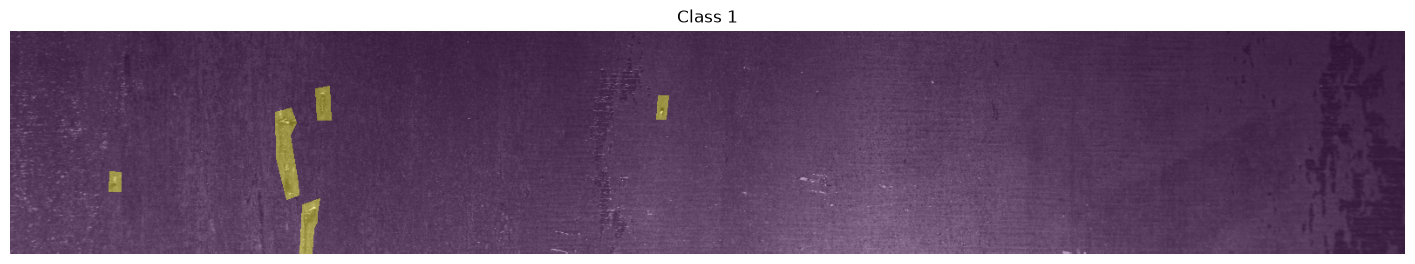

In [19]:
import matplotlib.pyplot as plt


if steel_train is not None:

    sample = steel_train.iloc[0]

    image_path = steel_images.get(
        sample["ImageId"]
    )

    if image_path is not None:

        image = Image.open(
            image_path
        ).convert("RGB")

        mask = decode_rle(
            sample["EncodedPixels"]
        )

        plt.figure(
            figsize=(18, 6)
        )

        plt.imshow(image)

        plt.imshow(
            mask,
            alpha=0.4
        )

        plt.axis("off")

        plt.title(
            f"Class {sample['ClassId']}"
        )

        plt.show()